## Moving Box

The impetus for this animation comes from this [stackoverflow](https://stackoverflow.com/questions/31921313/matplotlib-animation-moving-square) question which aligned with other practice animations I was exploring. Lets see if I can move the damn box appropriately.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib import animation

# interactive and display libraries
from IPython.display import HTML, display
from ipywidgets import interact, interactive, widgets
from ipywidgets import Image

In [26]:
# generate x values for model of data
maxtime = 2.0 # maximum time for model in s (intial time assumed 0)
numpoints = 200 # number of data points across the time interval
modeltime = np.linspace(0.,maxtime,numpoints) # linear distribution of data points across interval.

In [99]:
initVelX = 4.0 # initial velocity x in m/s
accelX = 3.2 # accel in m/s/s
initPositionX = 0.0 # initial position

In [100]:
xPosition = numpoints*[0]
yPosition = numpoints*[0]
yaw = numpoints*[0]

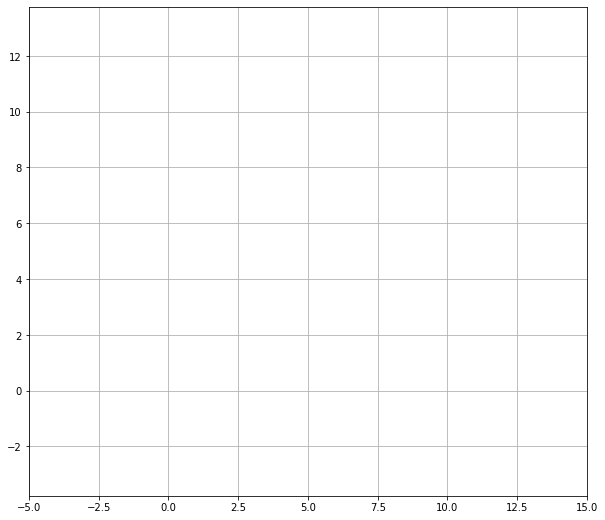

In [101]:
myFig, myAxes = plt.subplots()
myFig.set_size_inches(10, 9)
plt.axis('equal')
plt.grid()
myAxes.set_xlim(-5, 15)
myAxes.set_ylim(-5, 15)

plt.show()

In [114]:
patch = patches.Rectangle((0., 0.), 3., 3., edgecolor='red', linewidth = 2. ,facecolor = 'None')

In [115]:
def init():
    myAxes.add_patch(patch)
    return patch,

def animate(i):
    xPosition[i] = xPosition[0] + initVelX*modeltime[i] + accelX*modeltime[i]**2
    #yaw[i] = 10.*(modeltime[0]+1)  # rotation in degrees = 5*time
    patch.set_width(1.2)
    patch.set_height(1.0)
    patch.set_xy([xPosition[i], yPosition[i]])
    
    #trans1 = mpl.transforms.Affine2D().rotate_deg(yaw[i]) + myAxes.transData
    #patch.set_transform(trans1)
    #patch.set_angle = yaw[i]
    return patch,

In [116]:
anim = animation.FuncAnimation(myFig, animate,
                               init_func=init,
                               frames=len(xPosition),
                               interval=100,
                               blit=True)
plt.close(anim._fig)

In [117]:
# Display the animation
HTML(anim.to_html5_video())